<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day4_state_discovery/Day4_Project2_Celegans_MarkovChains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day 4, Project 2: C. elegans Behavior Analysis with Markov Chains

**Reference:** Costa et al., 2024 — *A Markovian dynamics for Caenorhabditis elegans behavior across scales* (PNAS)  
**Adapted from:** [OIST Physics of Behavior Tutorials](https://github.com/oist/Physics-of-Behavior-Tutorials)

---

## Learning Objectives

By the end of this project, you will be able to:

1. **Cluster** low-dimensional postural embeddings into discrete behavioral states using K-means
2. **Build transition matrices** from symbolic dynamics and interpret their structure
3. **Explain** what eigenvalues of a transition matrix tell us about behavioral timescales
4. **Detect macroscopic behavioral states** (runs vs. pirouettes) from spectral analysis
5. **Analyze** dwell times and transition rates between behavioral modes

## Project Overview

```
Part 1 (Done): Eigenworm PCA → 4D PC coefficients
                      ↓
Part 2 (This notebook): 
  Step A: Delay embedding → higher-D state space
  Step B: K-means clustering → discrete states (our clusters)
  Step C: Compare to pre-computed clusters
                      ↓
Part 3: Transition matrix → Eigenanalysis → Timescales
                      ↓  
Part 4: Macrostate detection → Runs & Pirouettes → Dwell times
```

## Setup

In [2]:
# Install required packages (run once)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'font.size': 14})
plt.rcParams['figure.figsize'] = (12, 6)

# Colorblind-friendly palette
CB_COLORS = ['#0077BB', '#EE7733', '#009988', '#CC3311', 
             '#33BBEE', '#EE3377', '#BBBBBB']

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


---

# Part 2: From Eigenworms to Behavioral Clusters

In Part 1 (the Eigenworms tutorial), we learned that C. elegans posture can be described by just 4 principal components (eigenworm coefficients). Each frame of the worm's movement is now a point in 4D space.

**The question:** How do we turn this continuous 4D trajectory into a sequence of discrete behavioral states?

**The answer:** We need two steps:
1. **Delay embedding** — stack consecutive frames to capture short-time dynamics
2. **K-means clustering** — partition the embedded space into discrete states

## 2.1 Load Eigenworm Coefficients

Let's load the eigenworm coefficients (PC projections) computed in Part 1.

In [4]:
# Download data from the OIST tutorial repository

!curl -sO https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/worm/eigenworm.npy
!curl -sO https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/worm/symbolic_dynamics.npy


# Load the eigenworm coefficients (PC projections from Part 1)
eigenworm = np.load('eigenworm.npy')

print(f"Eigenworm coefficients loaded!")
print(f"  Shape: {eigenworm.shape}")
print(f"  → {eigenworm.shape[0]} time frames, {eigenworm.shape[1]} PC dimensions")
print(f"  Sampling rate: 16 Hz (1 frame = 1/16 s ≈ 0.0625 s)")
print(f"  Total duration: {eigenworm.shape[0]/16:.1f} seconds")

Eigenworm coefficients loaded!
  Shape: (33600, 5)
  → 33600 time frames, 5 PC dimensions
  Sampling rate: 16 Hz (1 frame = 1/16 s ≈ 0.0625 s)
  Total duration: 2100.0 seconds


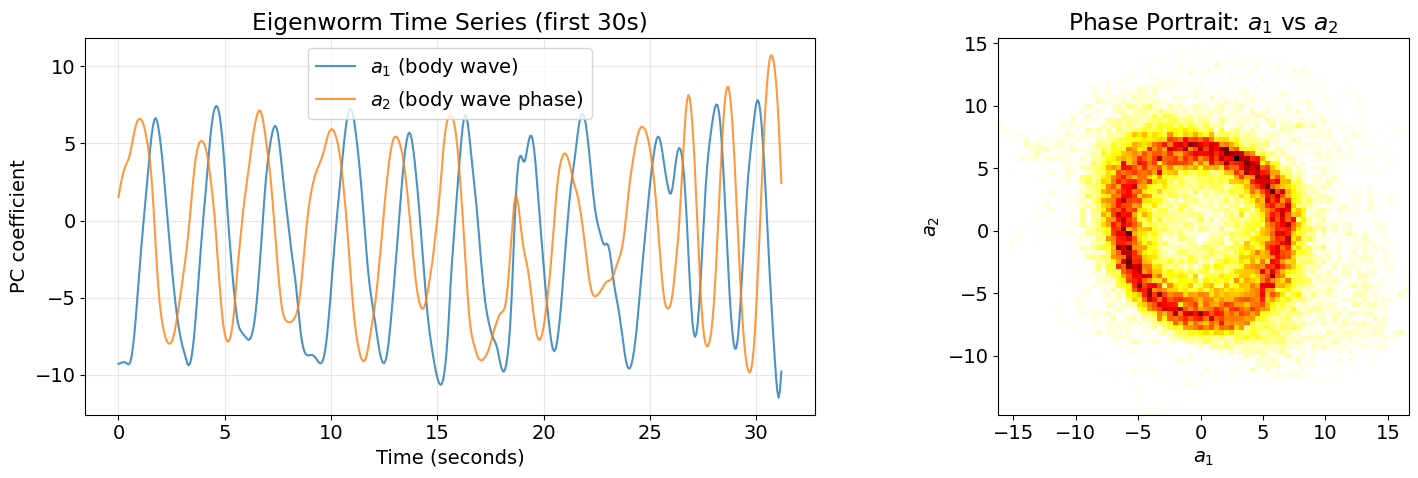

The ring-shaped phase portrait shows the worm's periodic crawling cycle.
Each revolution ≈ one body wave (forward or backward locomotion).


In [9]:
# Visualize the first two eigenworm coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series of first two PCs
time = np.arange(len(eigenworm)) / 16.0  # convert to seconds
axes[0].plot(time[:500], eigenworm[:500, 0], label='$a_1$ (body wave)', alpha=0.8)
axes[0].plot(time[:500], eigenworm[:500, 1], label='$a_2$ (body wave phase)', alpha=0.8)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('PC coefficient')
axes[0].set_title('Eigenworm Time Series (first 30s)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Phase portrait (a1 vs a2)
## remove the nan
clean_indices = ~np.isnan(eigenworm[:, 0]) & ~np.isnan(eigenworm[:, 1])
eigenworm_clean = eigenworm[clean_indices]
axes[1].hist2d(eigenworm_clean[:, 0], eigenworm_clean[:, 1], bins=80, cmap='hot_r')
axes[1].set_xlabel('$a_1$')
axes[1].set_ylabel('$a_2$')
axes[1].set_title('Phase Portrait: $a_1$ vs $a_2$')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print("The ring-shaped phase portrait shows the worm's periodic crawling cycle.")
print("Each revolution ≈ one body wave (forward or backward locomotion).")

## 2.2 Delay Embedding: Capturing Short-Time Dynamics

### Why delay embedding?

A single frame of eigenworm coefficients tells us the worm's *posture* at one instant, but not whether it's in the middle of a forward crawl or about to turn. By stacking $K$ consecutive frames together, we create a richer representation that captures the **short-time dynamics** — the recent history of the posture.

### The math

Given eigenworm coefficients $\vec{a}(t) = [a_1(t), a_2(t), a_3(t), a_4(t)]$, the delay-embedded vector at time $t$ with $K$ delays is:

$$X_{K}(t) = [\vec{a}(t),\; \vec{a}(t+1),\; \dots,\; \vec{a}(t+K-1)]$$

This maps each time point from 4D → $4K$ dimensions.

Following Costa et al. (2024), we use $K^* = 11$ frames (≈ 0.69 s), which maximizes predictability of the resulting Markov chain.

In [ ]:
def delay_embed(data, K):
    """
    Create delay-embedded state space.
    
    Parameters
    ----------
    data : array (n_frames, n_dims)
        Time series of eigenworm coefficients.
    K : int
        Number of delays (sequence length).
    
    Returns
    -------
    embedded : array (n_frames - K + 1, n_dims * K)
        Delay-embedded state space.
    """
    n_frames, n_dims = data.shape
    n_embedded = n_frames - K + 1
    embedded = np.zeros((n_embedded, n_dims * K))
    
    for i in range(K):
        ## TODO: Fill in the delay-embedded matrix
        embedded[:, i*n_dims:(i+1)*n_dims] = None
    return embedded

# Create delay-embedded state space
K_star = 11  # optimal delay from Costa et al. 2024
n_pcs = 4    # number of eigenworm components to use

X_embedded = delay_embed(eigenworm_clean[:, :n_pcs], K_star)

print(f"Delay embedding complete!")
print(f"  Original: {eigenworm_clean[:, :n_pcs].shape} → ({eigenworm_clean.shape[0]} frames × {n_pcs} PCs)")
print(f"  Embedded: {X_embedded.shape} → ({X_embedded.shape[0]} frames × {X_embedded.shape[1]}D)")
print(f"  Each point now captures {K_star} consecutive frames = {K_star/16:.3f} seconds of behavior")

Delay embedding complete!
  Original: (33166, 4) → (33166 frames × 4 PCs)
  Embedded: (33156, 44) → (33156 frames × 44D)
  Each point now captures 11 consecutive frames = 0.688 seconds of behavior


In [ ]:
#  embedded[:, i*n_dims:(i+1)*n_dims] = data[i:i+n_embedded]

## 2.3 K-Means Clustering: Creating Discrete States

### Why cluster?

Now that each time point lives in a high-dimensional embedded space, we partition this space into $N$ clusters using K-means. Each cluster represents a distinct short-time behavioral motif — a specific pattern of posture change over ~0.7 seconds.

### Choosing the number of clusters

Costa et al. use $N = 1000$ clusters, but for computational reasons in this tutorial we'll use $N = 500$ (which still captures the essential structure). The key insight is that we want *many* fine-grained microstates — the coarse-graining into meaningful behavioral categories will come later from the eigenanalysis of the transition matrix.

In [13]:
# =============================================================================
# K-Means Clustering on Delay-Embedded Space
# =============================================================================

N_clusters = 500  # Number of microstates

print(f"Running K-means with {N_clusters} clusters on {X_embedded.shape[0]} data points...")
print("(This may take 1-2 minutes...)")

kmeans = KMeans(n_clusters=N_clusters, random_state=42, n_init=5, max_iter=100)
our_labels = kmeans.fit_predict(X_embedded)

print(f"\n✓ Clustering complete!")
print(f"  Number of clusters: {len(np.unique(our_labels))}")
print(f"  Cluster sizes: min={np.bincount(our_labels).min()}, "
      f"max={np.bincount(our_labels).max()}, "
      f"mean={np.bincount(our_labels).mean():.1f}")

Running K-means with 500 clusters on 33156 data points...
(This may take 1-2 minutes...)

✓ Clustering complete!
  Number of clusters: 500
  Cluster sizes: min=6, max=254, mean=66.3


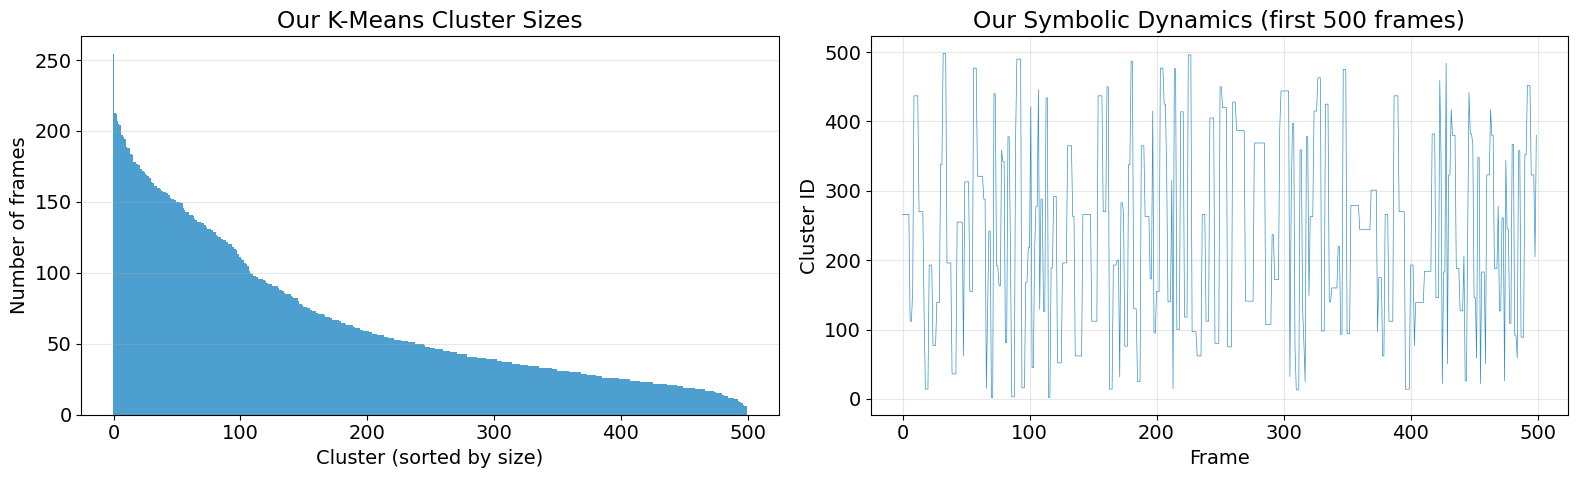

In [14]:
# Visualize cluster distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cluster size distribution
cluster_sizes = np.bincount(our_labels)
axes[0].bar(range(len(cluster_sizes)), np.sort(cluster_sizes)[::-1], 
            width=1, edgecolor='none', alpha=0.7, color=CB_COLORS[0])
axes[0].set_xlabel('Cluster (sorted by size)')
axes[0].set_ylabel('Number of frames')
axes[0].set_title('Our K-Means Cluster Sizes')
axes[0].grid(alpha=0.3, axis='y')

# Symbolic dynamics time series (first 500 frames)
axes[1].plot(our_labels[:500], linewidth=0.5, alpha=0.8, color=CB_COLORS[0])
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Cluster ID')
axes[1].set_title('Our Symbolic Dynamics (first 500 frames)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## ✏️ Exercise 1: Explore Different Numbers of Clusters

Try K-means with different numbers of clusters (e.g., 50, 200, 500, 1000) and observe how the cluster size distribution changes. What do you notice?

**Hint:** Use `KMeans(n_clusters=N, random_state=42, n_init=3).fit_predict(X_embedded)`

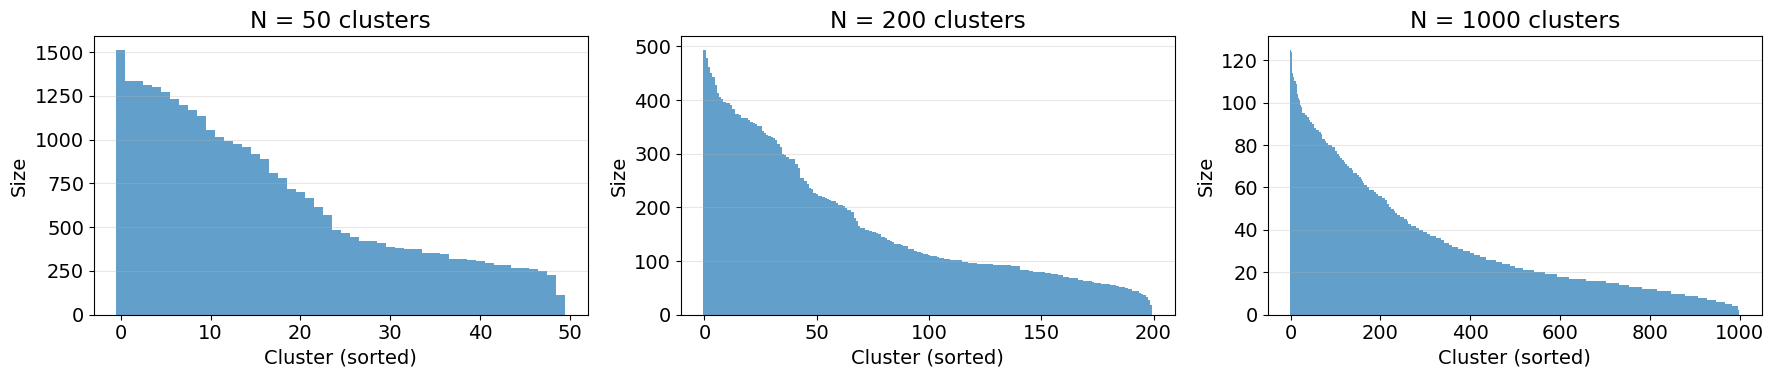

More clusters → more uniform sizes → finer behavioral resolution
But too many clusters → some clusters have very few data points → noisy estimates


In [ ]:
# =============================================================================
# EXERCISE 1: Try different numbers of clusters
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, N in zip(axes, [50, 200, 1000]):
    # TODO: Run K-means with N = 50, 200, 1000
    km = None 
    labels_test = km.fit_predict(X_embedded)
    sizes = np.sort(np.bincount(labels_test))[::-1]
    ax.bar(range(len(sizes)), sizes, width=1, edgecolor='none', alpha=0.7)
    ax.set_title(f'N = {N} clusters')
    ax.set_xlabel('Cluster (sorted)')
    ax.set_ylabel('Size')
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("More clusters → more uniform sizes → finer behavioral resolution")
print("But too many clusters → some clusters have very few data points → noisy estimates")

In [ ]:
# km = KMeans(n_clusters=N, random_state=42, n_init=3, max_iter=50)


## 2.5 Choosing Which Clustering to Use

For the rest of this tutorial, we will use the **pre-computed symbolic dynamics** from Costa et al., because:
1. They were generated with a more principled method (maximum entropy partitioning)
2. They are well-validated in the published paper
3. This lets us compare our results directly to the paper's findings

However, the methods we apply next (transition matrix, eigenanalysis, spectral clustering) work equally well with *our* K-means clusters — you are encouraged to try it as an optional exercise!

In [19]:
# Use pre-computed symbolic dynamics for subsequent analysis
symbols = our_labels.copy()

print(f"Using pre-computed symbolic dynamics:")
print(f"  {len(symbols)} time points, {len(np.unique(symbols))} unique states")
print(f"  Duration: {len(symbols)/16:.1f} seconds")

Using pre-computed symbolic dynamics:
  33156 time points, 500 unique states
  Duration: 2072.2 seconds


---

# Part 3: Transition Matrix and Timescale Analysis

Now we have a sequence of discrete states (symbols). The next step is to build a **transition matrix** that captures the probability of moving from one state to another.

## 3.1 Building the Transition Matrix

### The math (before we code)

Given a symbolic sequence $s_1, s_2, \dots, s_T$ with $N$ unique states, the transition matrix $P$ has entries:

$$P_{ij}(\tau) = \frac{\text{number of times state } i \text{ is followed by state } j \text{ after } \tau \text{ steps}}{\text{total times state } i \text{ is visited}}$$

Each row sums to 1 (it's a probability distribution over next states). The parameter $\tau$ is the **lag time** — how many steps ahead we look.

In [20]:
def compute_transition_matrix(time_series, n_transitions=1):
    """
    Compute transition matrix from a symbolic time series.
    
    Parameters
    ----------
    time_series : array (T,)
        Sequence of discrete state labels.
    n_transitions : int
        Lag time (number of steps between current and next state).
    
    Returns
    -------
    T : array (N, N)
        Row-stochastic transition matrix.
    """
    states = np.unique(time_series)
    num_states = len(states)
    T = np.zeros((num_states, num_states), dtype=float)
    state_to_idx = {s: i for i, s in enumerate(states)}
    
    for curr, nxt in zip(time_series[:-n_transitions], time_series[n_transitions:]):
        T[state_to_idx[curr], state_to_idx[nxt]] += 1
    
    # Normalize rows
    row_sums = T.sum(axis=1, keepdims=True)
    T = np.divide(T, row_sums, where=row_sums != 0)
    
    return T

# Compute transition matrix with lag = 10 steps
n_lag = 10
tm = compute_transition_matrix(symbols, n_transitions=n_lag)

print(f"Transition matrix computed!")
print(f"  Shape: {tm.shape} ({tm.shape[0]} states × {tm.shape[1]} states)")
print(f"  Lag time: {n_lag} steps = {n_lag/16:.3f} seconds")
print(f"  Sparsity: {np.sum(tm == 0) / tm.size * 100:.1f}% entries are zero")
print(f"  → Most transitions are forbidden! Strong behavioral structure.")

Transition matrix computed!
  Shape: (500, 500) (500 states × 500 states)
  Lag time: 10 steps = 0.625 seconds
  Sparsity: 97.6% entries are zero
  → Most transitions are forbidden! Strong behavioral structure.


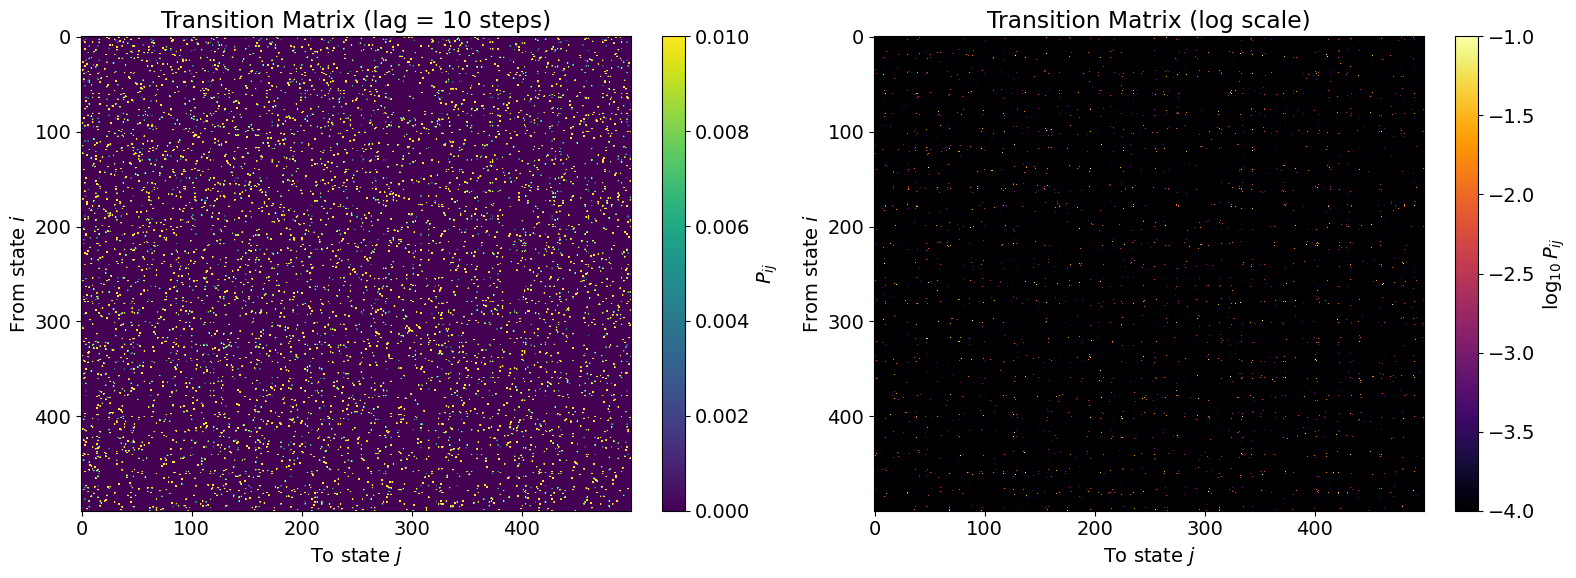

The block-like structure visible in the matrix reveals clusters of
states that preferentially transition among themselves — these are
the behavioral modes we want to identify!


In [21]:
# Visualize transition matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full matrix
im = axes[0].imshow(tm, cmap='viridis', vmax=0.01, aspect='auto')
plt.colorbar(im, ax=axes[0], label='$P_{ij}$', fraction=0.046)
axes[0].set_xlabel('To state $j$')
axes[0].set_ylabel('From state $i$')
axes[0].set_title(f'Transition Matrix (lag = {n_lag} steps)')

# Log-scale view to see structure
tm_log = np.log10(tm + 1e-10)
im2 = axes[1].imshow(tm_log, cmap='inferno', aspect='auto', vmin=-4, vmax=-1)
plt.colorbar(im2, ax=axes[1], label='$\log_{10} P_{ij}$', fraction=0.046)
axes[1].set_xlabel('To state $j$')
axes[1].set_ylabel('From state $i$')
axes[1].set_title('Transition Matrix (log scale)')

plt.tight_layout()
plt.show()

print("The block-like structure visible in the matrix reveals clusters of")
print("states that preferentially transition among themselves — these are")
print("the behavioral modes we want to identify!")

## 3.2 Eigenanalysis: What Eigenvalues Tell Us About Timescales

This is the key insight of the Markov chain approach. Let's build the intuition step by step.

### The core idea

The state of the system at time $t$ (a probability distribution over all states) evolves as:

$$\vec{p}(t) = P^t \vec{p}(0)$$

Using the eigendecomposition $P = \sum_i \lambda_i \vec{v}_i \vec{u}_i^T$, this becomes:

$$\vec{p}(t) = \sum_{i=1}^{N} \lambda_i^t \, c_i \, \vec{v}_i$$

### What each eigenvalue tells us

| Eigenvalue | Meaning | Timescale |
|:---:|:---|:---|
| $\lambda_1 = 1$ | **Steady state** — the system has fully equilibrated | $\tau = \infty$ |
| $\lambda_2 \approx 1$ | **Slowest mode** — takes a long time to decay | $\tau_2 = -1/\ln(\lambda_2)$ (long) |
| $\lambda_i \ll 1$ | **Fast modes** — decay quickly, transient dynamics | $\tau_i$ (short) |

### Why does $\lambda_i^t$ give us timescales?

Think of $\lambda_i^t$ as the **"memory"** of mode $i$ after $t$ steps:

- If $\lambda = 0.99$: after 100 steps, $0.99^{100} = 0.37$ → still 37% of original signal. **Slow decay.**
- If $\lambda = 0.5$: after 100 steps, $0.5^{100} \approx 0$ → signal is gone. **Fast decay.**

The **relaxation time** $\tau_i = \frac{-1}{\ln(\lambda_i)}$ tells us how many steps it takes for mode $i$ to decay by a factor of $e \approx 2.72$.

### A gap in eigenvalues = a separation of timescales

If there is a **gap** between $\lambda_2$ and $\lambda_3$, it means:
- The slowest non-trivial mode ($\lambda_2$) lives much longer than all faster modes
- This creates two well-separated groups of states = **metastable states**
- The system spends a long time in each group before switching

In [ ]:
# Eigenanalysis of the transition matrix
## TODO: Compute eigenvalues and eigenvectors of the transition matrix
eigvals, eigvecs = None, None

# Sort by descending real part of eigenvalues
idx = np.argsort(eigvals.real)[::-1]
eigvals = eigvals[idx].real  # small imaginary parts are numerical noise
eigvecs = eigvecs[:, idx].real

print("Top 10 eigenvalues:")
for i in range(10):
    if eigvals[i] > 0 and eigvals[i] < 1:
        tau = -1.0 / np.log(eigvals[i])
        tau_seconds = tau * n_lag / 16.0  # convert to real seconds
        print(f"  λ{i+1} = {eigvals[i]:.5f}  →  τ = {tau:.1f} steps = {tau_seconds:.2f} seconds")
    else:
        print(f"  λ{i+1} = {eigvals[i]:.5f}  →  (steady state)" if eigvals[i] >= 0.9999 else f"  λ{i+1} = {eigvals[i]:.5f}")

Top 10 eigenvalues:
  λ1 = 1.00000  →  (steady state)
  λ2 = 0.84007  →  τ = 5.7 steps = 3.59 seconds
  λ3 = 0.68978  →  τ = 2.7 steps = 1.68 seconds
  λ4 = 0.68978  →  τ = 2.7 steps = 1.68 seconds
  λ5 = 0.62048  →  τ = 2.1 steps = 1.31 seconds
  λ6 = 0.62048  →  τ = 2.1 steps = 1.31 seconds
  λ7 = 0.61764  →  τ = 2.1 steps = 1.30 seconds
  λ8 = 0.55397  →  τ = 1.7 steps = 1.06 seconds
  λ9 = 0.55397  →  τ = 1.7 steps = 1.06 seconds
  λ10 = 0.54610  →  τ = 1.7 steps = 1.03 seconds


In [ ]:
eigvals, eigvecs  = np.linalg.eig(tm)

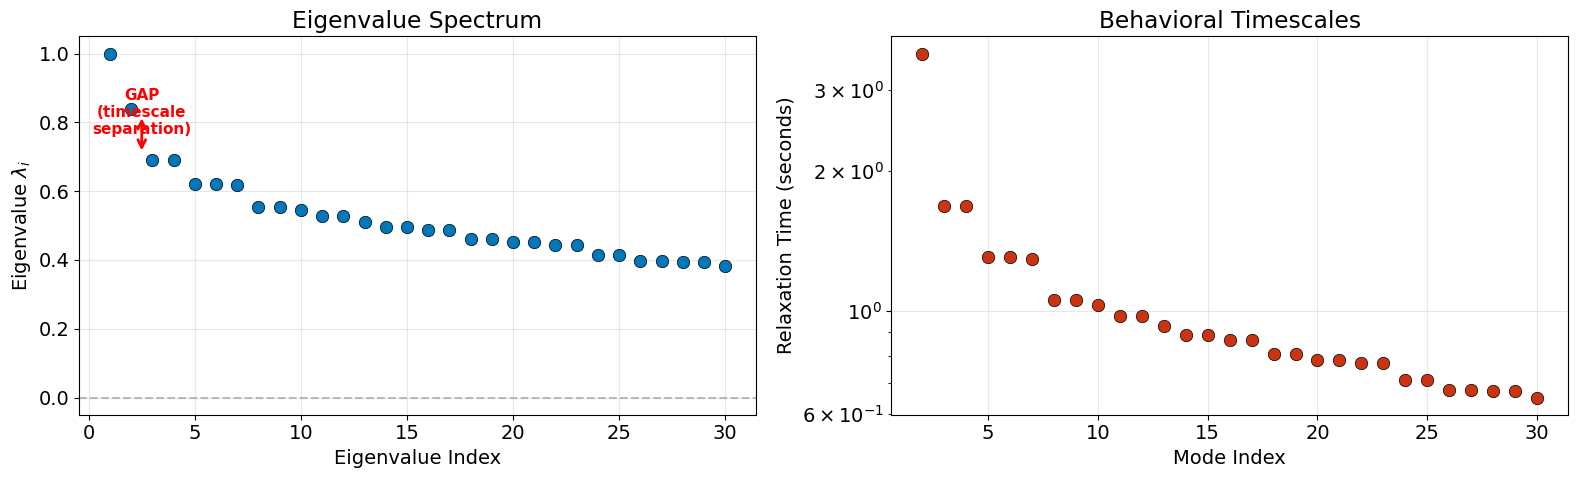

Key finding:
  Slowest mode (λ₂): τ ≈ 3.6 seconds — this is the 'run-and-pirouette' timescale
  Next modes (λ₃₋₅): τ ≈ 1.7-1.3 seconds — finer behavioral structure
  The GAP between λ₂ and λ₃ confirms a dominant two-state dynamics!


In [23]:
# Visualize eigenvalue spectrum and timescales
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

n_show = 30

# Eigenvalue spectrum
axes[0].scatter(range(1, n_show+1), eigvals[:n_show], s=80, 
                color=CB_COLORS[0], edgecolors='k', linewidths=0.5, zorder=3)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Highlight the gap
axes[0].annotate('GAP\n(timescale\nseparation)', 
                xy=(2.5, (eigvals[1]+eigvals[2])/2), fontsize=11,
                ha='center', color='red', fontweight='bold')
axes[0].annotate('', xy=(2.5, eigvals[1]-0.02), xytext=(2.5, eigvals[2]+0.02),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))

axes[0].set_xlabel('Eigenvalue Index')
axes[0].set_ylabel('Eigenvalue $\lambda_i$')
axes[0].set_title('Eigenvalue Spectrum')
axes[0].grid(alpha=0.3)

# Relaxation timescales
valid = (eigvals[1:n_show] > 0) & (eigvals[1:n_show] < 1)
timescales = np.where(valid, -1.0 / np.log(eigvals[1:n_show]), 0)
timescales_sec = timescales * n_lag / 16.0

axes[1].scatter(range(2, n_show+1), timescales_sec, s=80,
                color=CB_COLORS[3], edgecolors='k', linewidths=0.5, zorder=3)
axes[1].set_xlabel('Mode Index')
axes[1].set_ylabel('Relaxation Time (seconds)')
axes[1].set_title('Behavioral Timescales')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Key finding:")
print(f"  Slowest mode (λ₂): τ ≈ {timescales_sec[0]:.1f} seconds — this is the 'run-and-pirouette' timescale")
print(f"  Next modes (λ₃₋₅): τ ≈ {timescales_sec[1]:.1f}-{timescales_sec[3]:.1f} seconds — finer behavioral structure")
print(f"  The GAP between λ₂ and λ₃ confirms a dominant two-state dynamics!")

## ✏️ Exercise 2: Eigenvalue Decay Visualization

To build intuition about what eigenvalues mean for timescales, plot $\lambda_2^t$ and $\lambda_5^t$ as a function of time $t$ (from 0 to 200 steps). Which mode "forgets" its initial conditions faster?

**Hint:** This is just computing a power: `lambda_val ** t` for an array of `t` values.

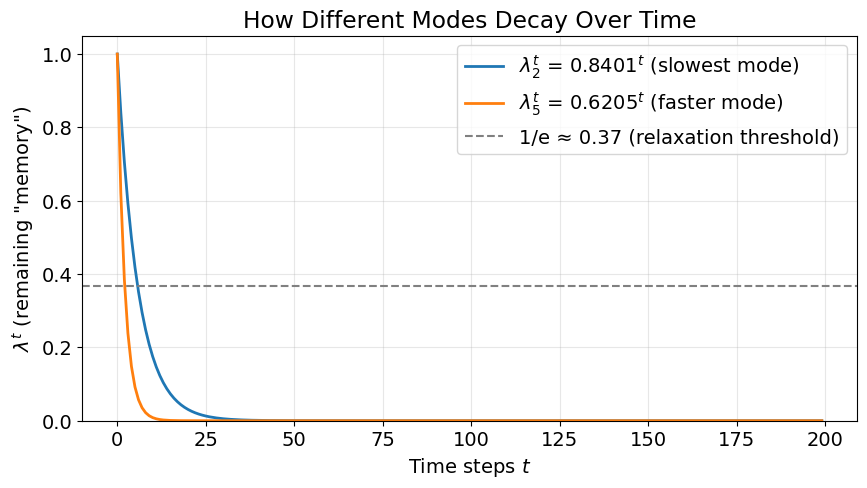

λ₂ crosses 1/e at t ≈ 5.7 steps → slow mode (run↔pirouette switching)
λ₅ crosses 1/e at t ≈ 2.1 steps → fast mode (within-state fluctuations)


In [ ]:
# =============================================================================
# EXERCISE 2: Visualize eigenvalue decay
# =============================================================================
# TODO: Plot lambda_2^t and lambda_5^t on the same axes
t = np.arange(0, 200)
lam2, lam5 = eigvals[1], eigvals[4]
res2 = None
res5 = None
plt.figure(figsize=(10, 5))
plt.plot(t, res2, linewidth=2, label=f'$\lambda_2^t$ = {lam2:.4f}$^t$ (slowest mode)')
plt.plot(t, res5, linewidth=2, label=f'$\lambda_5^t$ = {lam5:.4f}$^t$ (faster mode)')
plt.axhline(1/np.e, color='gray', linestyle='--', label=f'1/e ≈ {1/np.e:.2f} (relaxation threshold)')
plt.xlabel('Time steps $t$')
plt.ylabel('$\lambda^t$ (remaining "memory")')
plt.title('How Different Modes Decay Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim([0, 1.05])
plt.show()



tau2 = -1/np.log(lam2)
tau5 = -1/np.log(lam5)
print(f"λ₂ crosses 1/e at t ≈ {tau2:.1f} steps → slow mode (run↔pirouette switching)")
print(f"λ₅ crosses 1/e at t ≈ {tau5:.1f} steps → fast mode (within-state fluctuations)")

## 3.3 Spectral Clustering: From Microstates to Macrostates

### The key idea

The **second eigenvector** $\vec{v}_2$ of the transition matrix naturally divides the state space into two groups:
- States where $v_2 > 0$: one macrostate
- States where $v_2 < 0$: the other macrostate

This is called **spectral clustering**. It works because states within the same macrostate transition frequently among themselves (they are "dynamically close"), while transitions *between* macrostates are rare.

In the C. elegans context, Costa et al. (2024) showed that:
- **$v_2 < 0$** → Forward locomotion ("runs")
- **$v_2 > 0$** → Reorientation events ("pirouettes": reversals, turns)

In [36]:
# Spectral clustering using eigenvector 2
evec2 = eigvecs[:, 1]  # second eigenvector (skip λ₁=1)

# Assign each microstate to a macrostate based on sign of v2
macro_labels = (evec2 > 0).astype(int)  # 0 = runs, 1 = pirouettes

print(f"Spectral clustering into 2 macrostates:")
print(f"  Macrostate 0 (runs):       {np.sum(macro_labels == 0)} microstates")
print(f"  Macrostate 1 (pirouettes): {np.sum(macro_labels == 1)} microstates")

# Map each time point to its macrostate
macro_sequence = macro_labels[symbols]

# Count time in each macrostate
n_run = np.sum(macro_sequence == 0)
n_pir = np.sum(macro_sequence == 1)
print(f"\nTime allocation:")
print(f"  Runs:       {n_run/len(macro_sequence)*100:.1f}% of time")
print(f"  Pirouettes: {n_pir/len(macro_sequence)*100:.1f}% of time")

Spectral clustering into 2 macrostates:
  Macrostate 0 (runs):       266 microstates
  Macrostate 1 (pirouettes): 234 microstates

Time allocation:
  Runs:       29.5% of time
  Pirouettes: 70.5% of time


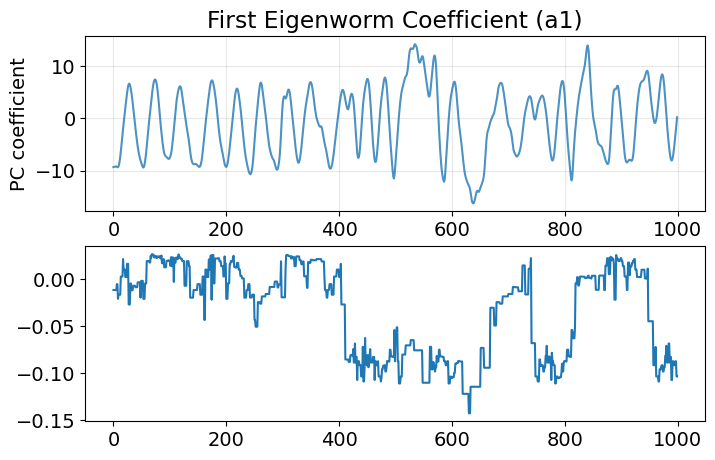

In [46]:
# visualize the conrresponding between eigenworm and the macrostate labels
fig, axes = plt.subplots(2, 1, figsize=(8, 5))
# plot the value of first eigenvector 
t = np.arange(0,1000)
axes[0].plot(t, eigenworm_clean[:1000, 0], label='a1 (body wave)', alpha=0.8)
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('PC coefficient')
axes[0].set_title('First Eigenworm Coefficient (a1)')
axes[0].grid(alpha=0.3)

## plot the macrostate labels
axes[1].plot(t, evec2[symbols[:1000]])

The second eigenvector shows slower dynamics compared to the original eigenworm time series. In the paper, it has been revealed that the second eigenvector corresponds to ''runs-and-pirouettes'' behavior. Basically, positive values in $v_2$ correspond to combinations of reversals and turns that reorient the worm, these are “pirouettes”, while
negative values correspond to “forward runs”. They color the state space and an exemplar centroid trajectory
(inset) by the second eigenvector $v_2$ (denoted $\phi_2$ in the figure). The trajectory is nicely segmented into pirouettes (blue, positive eigenvector value) and run (red, negative value).

<img src= "attach_figure/worm_eigenvector.jpg" alt="processed image" align="middle" width="600"/>


### The rest part will be the bonus part. 

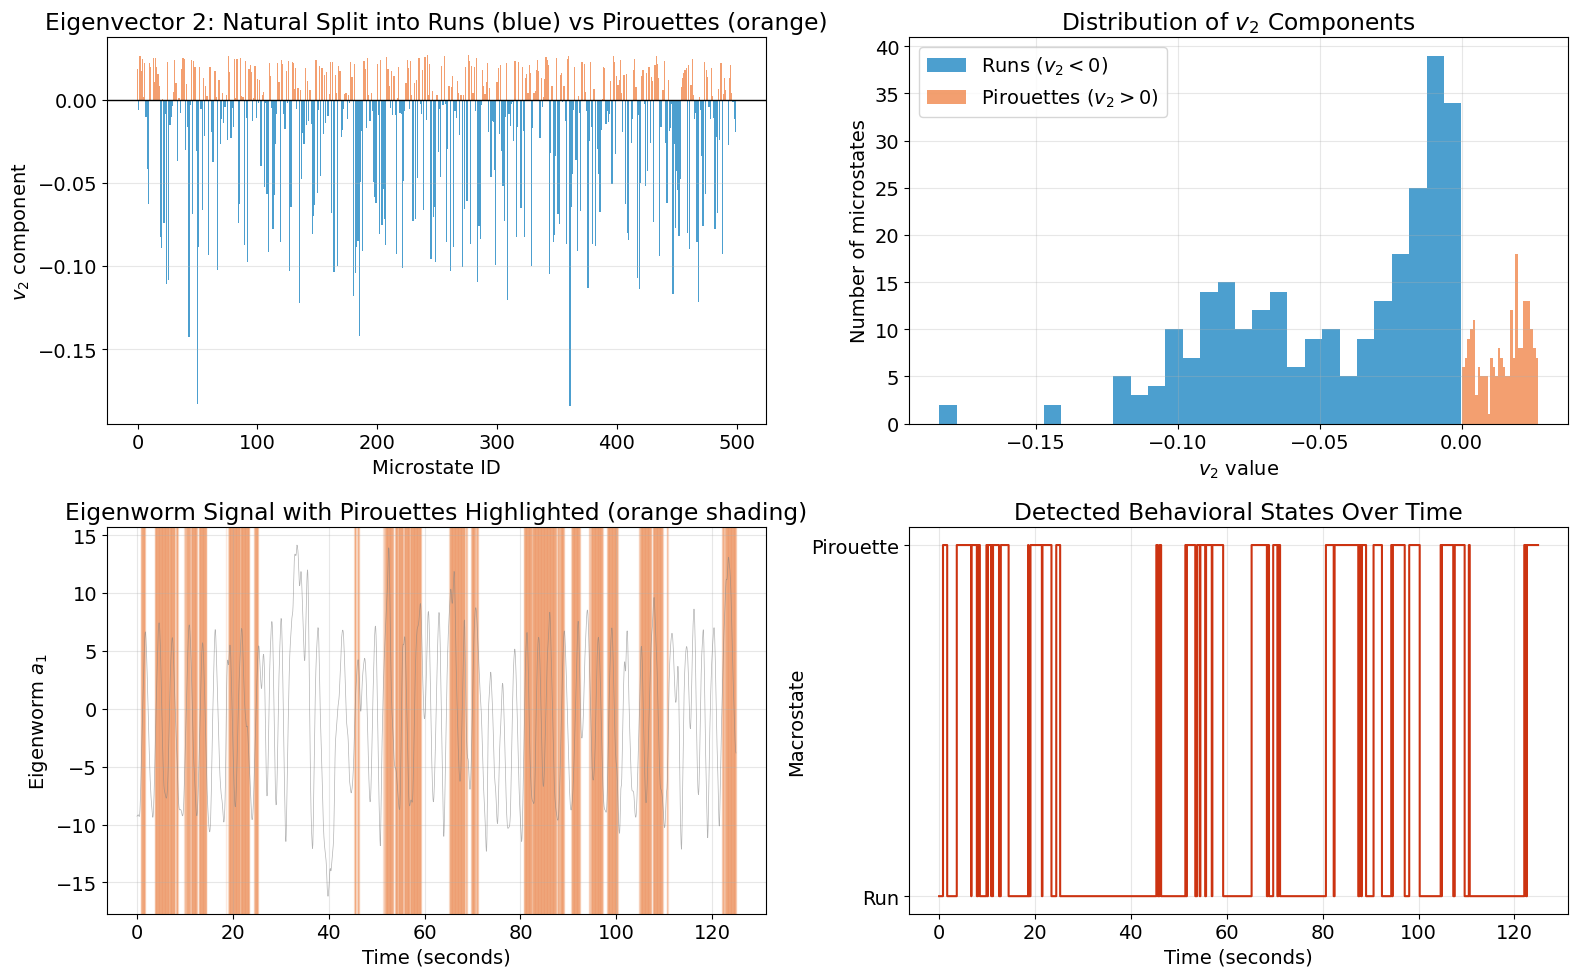

In [26]:
# Visualize the eigenvector-based clustering
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Eigenvector 2 values for each state
axes[0,0].bar(range(len(evec2)), evec2, width=1, 
              color=[CB_COLORS[0] if v <= 0 else CB_COLORS[1] for v in evec2],
              edgecolor='none', alpha=0.7)
axes[0,0].axhline(0, color='black', linewidth=1)
axes[0,0].set_xlabel('Microstate ID')
axes[0,0].set_ylabel('$v_2$ component')
axes[0,0].set_title('Eigenvector 2: Natural Split into Runs (blue) vs Pirouettes (orange)')
axes[0,0].grid(alpha=0.3, axis='y')

# Histogram of eigenvector values
axes[0,1].hist(evec2[evec2 <= 0], bins=30, alpha=0.7, color=CB_COLORS[0], label='Runs ($v_2 < 0$)')
axes[0,1].hist(evec2[evec2 > 0], bins=30, alpha=0.7, color=CB_COLORS[1], label='Pirouettes ($v_2 > 0$)')
axes[0,1].set_xlabel('$v_2$ value')
axes[0,1].set_ylabel('Number of microstates')
axes[0,1].set_title('Distribution of $v_2$ Components')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Macro-sequence vs original time series
time_s = np.arange(len(macro_sequence)) / 16.0
plot_range = slice(0, 2000)
eigenworm_aligned = eigenworm[:len(macro_sequence)]

axes[1,0].plot(time_s[plot_range], eigenworm_aligned[plot_range, 0], 
               linewidth=0.5, alpha=0.6, color='gray', label='$a_1(t)$')
# Color background by macrostate
for t in range(plot_range.start, plot_range.stop - 1):
    if macro_sequence[t] == 1:  # pirouette
        axes[1,0].axvspan(time_s[t], time_s[t+1], alpha=0.15, color=CB_COLORS[1])
axes[1,0].set_xlabel('Time (seconds)')
axes[1,0].set_ylabel('Eigenworm $a_1$')
axes[1,0].set_title('Eigenworm Signal with Pirouettes Highlighted (orange shading)')
axes[1,0].grid(alpha=0.3)

# Macro-state time series
axes[1,1].plot(time_s[plot_range], macro_sequence[plot_range], 
               drawstyle='steps-post', linewidth=1.5, color=CB_COLORS[3])
axes[1,1].set_xlabel('Time (seconds)')
axes[1,1].set_ylabel('Macrostate')
axes[1,1].set_yticks([0, 1])
axes[1,1].set_yticklabels(['Run', 'Pirouette'])
axes[1,1].set_title('Detected Behavioral States Over Time')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3.4 Comparing Spectral Clustering to a Simple Threshold

Traditionally, researchers identify runs and pirouettes using simple thresholds on body wave velocity and curvature (e.g., Costa et al. Fig. 2C). Let's create a simple threshold-based classification and compare it to our spectral clustering.

This comparison validates that the Markov chain eigenanalysis recovers biologically meaningful states *without* requiring manual threshold tuning.

In [47]:
# Simple threshold-based classification using eigenworm coefficients
# Body wave velocity ∝ d/dt(arctan(a2/a1)) — we approximate with angular velocity
a1 = eigenworm_aligned[:, 0]
a2 = eigenworm_aligned[:, 1]

# Phase angle and its derivative (body wave velocity)
phase = np.arctan2(a2, a1)
phase_velocity = np.diff(np.unwrap(phase)) * 16  # multiply by sampling rate

# Total curvature ∝ sum of higher eigenworm modes
if eigenworm.shape[1] > 2:
    curvature = np.sum(eigenworm_aligned[:, 2:], axis=1)
else:
    curvature = np.zeros(len(eigenworm_aligned))

# Simple threshold: pirouette = low phase velocity OR high curvature
threshold_labels = np.zeros(len(macro_sequence), dtype=int)
# Use amplitude of oscillation as proxy
amplitude = np.sqrt(a1**2 + a2**2)
# Low amplitude + irregular motion → pirouette
# We use a simple rule: if phase velocity magnitude is low → pirouette
pv_padded = np.append(phase_velocity, phase_velocity[-1])  # pad to match length
threshold_labels[np.abs(pv_padded) < np.percentile(np.abs(pv_padded), 20)] = 1

# Agreement between methods
agreement = np.mean(macro_sequence == threshold_labels)
ari_macro = adjusted_rand_score(macro_sequence, threshold_labels)

print(f"Comparison: Spectral Clustering vs Simple Threshold")
print(f"  Raw agreement: {agreement*100:.1f}%")
print(f"  Adjusted Rand Index: {ari_macro:.3f}")
print(f"\nThe methods partially agree, but spectral clustering is more principled")
print(f"because it uses the full dynamics (transition matrix) rather than instantaneous features.")

Comparison: Spectral Clustering vs Simple Threshold
  Raw agreement: 29.5%
  Adjusted Rand Index: 0.000

The methods partially agree, but spectral clustering is more principled
because it uses the full dynamics (transition matrix) rather than instantaneous features.


---

# Part 4: Behavioral State Detection and Further Analysis

Now that we have identified runs and pirouettes from the eigenvector analysis, let's characterize these behavioral states in detail.

## 4.1 Dwell Time Analysis

### The math

The **dwell time** is how long the system stays in a macrostate before switching. For a two-state Markov chain, the dwell time distribution should be approximately **exponential**:

$$P(\tau_{\text{dwell}} > t) = e^{-t/\langle\tau\rangle}$$

where $\langle\tau\rangle$ is the mean dwell time. If the distribution deviates from exponential, it suggests non-Markovian dynamics or sub-structure within the macrostate.

In [48]:
def compute_dwell_times(state_sequence):
    """
    Compute dwell times for each state in a binary sequence.
    
    Returns dict: {state_id: array of dwell times (in frames)}
    """
    dwells = {0: [], 1: []}
    current_state = state_sequence[0]
    current_duration = 1
    
    for i in range(1, len(state_sequence)):
        if state_sequence[i] == current_state:
            current_duration += 1
        else:
            dwells[current_state].append(current_duration)
            current_state = state_sequence[i]
            current_duration = 1
    dwells[current_state].append(current_duration)  # last segment
    
    return {k: np.array(v) for k, v in dwells.items()}

# Compute dwell times
dwell_times = compute_dwell_times(macro_sequence)

# Convert to seconds
dt_frame = 1.0 / 16.0  # seconds per frame
dwell_runs_sec = dwell_times[0] * dt_frame
dwell_pir_sec = dwell_times[1] * dt_frame

print(f"Dwell Time Statistics:")
print(f"\n  Runs:")
print(f"    Number of episodes: {len(dwell_runs_sec)}")
print(f"    Mean duration: {np.mean(dwell_runs_sec):.2f} s")
print(f"    Median duration: {np.median(dwell_runs_sec):.2f} s")
print(f"    Max duration: {np.max(dwell_runs_sec):.2f} s")
print(f"\n  Pirouettes:")
print(f"    Number of episodes: {len(dwell_pir_sec)}")
print(f"    Mean duration: {np.mean(dwell_pir_sec):.2f} s")
print(f"    Median duration: {np.median(dwell_pir_sec):.2f} s")
print(f"    Max duration: {np.max(dwell_pir_sec):.2f} s")

Dwell Time Statistics:

  Runs:
    Number of episodes: 425
    Mean duration: 1.44 s
    Median duration: 0.25 s
    Max duration: 20.56 s

  Pirouettes:
    Number of episodes: 425
    Mean duration: 3.44 s
    Median duration: 1.06 s
    Max duration: 56.88 s


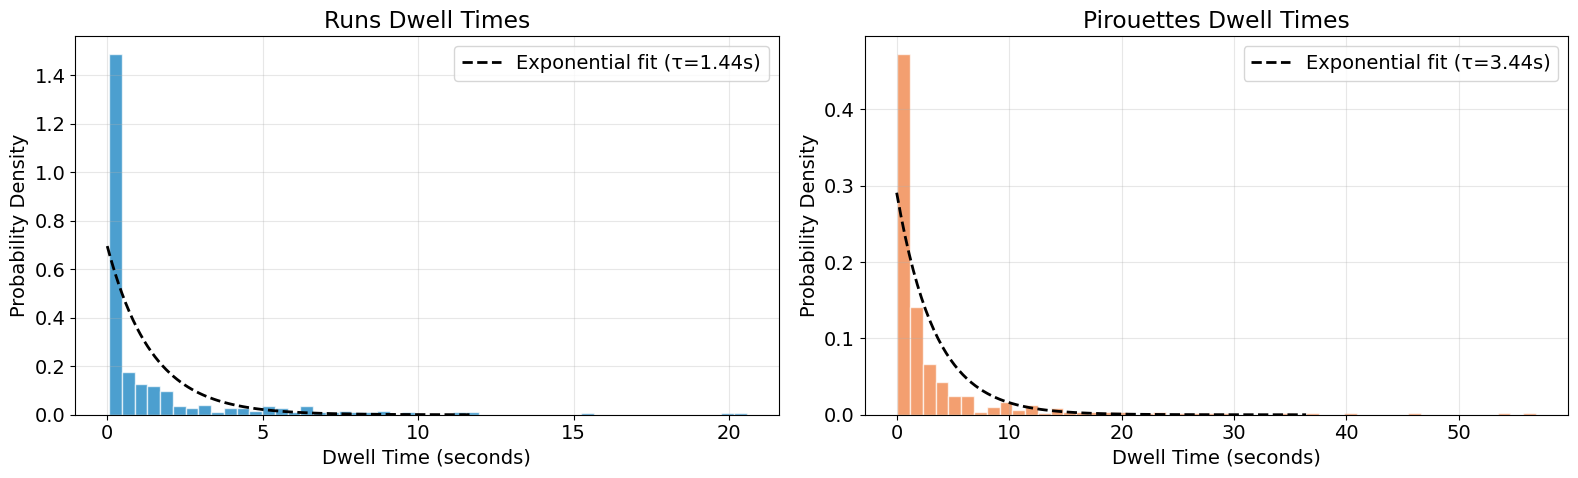

If dwell times follow an exponential distribution, the two-state
Markov model is a good description. Deviations suggest sub-structure.


In [49]:
# Visualize dwell time distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograms
for ax, data, label, color in zip(axes, 
    [dwell_runs_sec, dwell_pir_sec],
    ['Runs', 'Pirouettes'],
    [CB_COLORS[0], CB_COLORS[1]]):
    
    ax.hist(data, bins=50, density=True, alpha=0.7, color=color, edgecolor='white')
    
    # Fit exponential
    mean_dwell = np.mean(data)
    x_fit = np.linspace(0, np.percentile(data, 99), 100)
    ax.plot(x_fit, (1/mean_dwell) * np.exp(-x_fit/mean_dwell), 
            'k--', linewidth=2, label=f'Exponential fit (τ={mean_dwell:.2f}s)')
    
    ax.set_xlabel('Dwell Time (seconds)')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'{label} Dwell Times')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("If dwell times follow an exponential distribution, the two-state")
print("Markov model is a good description. Deviations suggest sub-structure.")

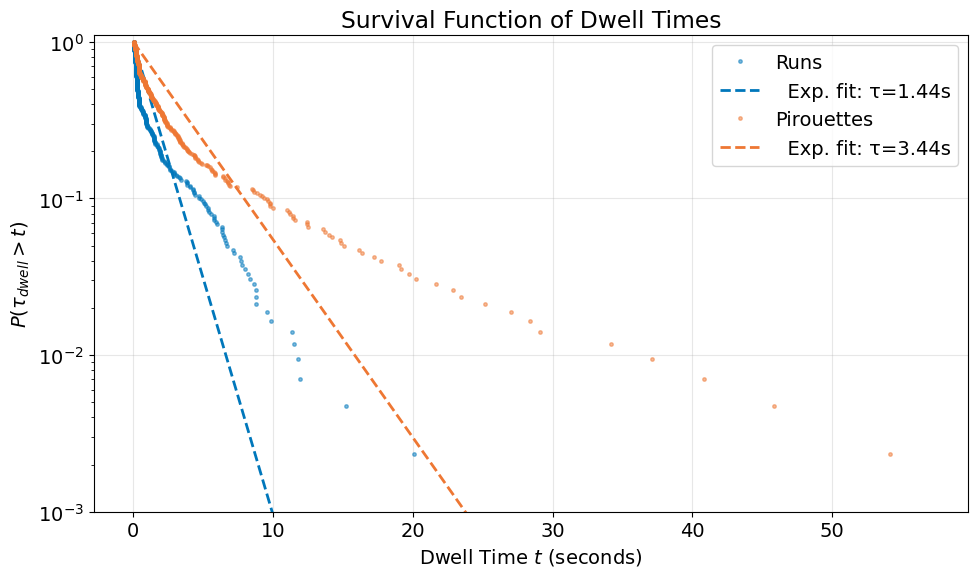

A straight line on the log scale = perfect exponential (Markov)
A curved line suggests multiple sub-states with different timescales
(This is consistent with Costa et al. Fig. 4B, which found TWO timescales)


In [50]:
# Complementary cumulative distribution (survival function)
# This is the key diagnostic — on a log scale, exponential = straight line

fig, ax = plt.subplots(figsize=(10, 6))

for data, label, color in zip(
    [dwell_runs_sec, dwell_pir_sec],
    ['Runs', 'Pirouettes'],
    [CB_COLORS[0], CB_COLORS[1]]):
    
    sorted_data = np.sort(data)
    survival = 1 - np.arange(1, len(sorted_data)+1) / len(sorted_data)
    ax.semilogy(sorted_data, survival, '.', color=color, alpha=0.5, markersize=5, label=label)
    
    # Exponential fit line
    mean_dwell = np.mean(data)
    x_fit = np.linspace(0, sorted_data[-1], 200)
    ax.semilogy(x_fit, np.exp(-x_fit/mean_dwell), '--', color=color, linewidth=2,
                label=f'  Exp. fit: τ={mean_dwell:.2f}s')

ax.set_xlabel('Dwell Time $t$ (seconds)')
ax.set_ylabel('$P(\\tau_{dwell} > t)$')
ax.set_title('Survival Function of Dwell Times')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([1e-3, 1.1])
plt.tight_layout()
plt.show()

print("A straight line on the log scale = perfect exponential (Markov)")
print("A curved line suggests multiple sub-states with different timescales")
print("(This is consistent with Costa et al. Fig. 4B, which found TWO timescales)")

## ✏️ Exercise 3: Compute Transition Rates Between Macrostates

Compute the 2×2 transition matrix between the macrostates (runs and pirouettes). From this, calculate:
1. The transition rate from runs to pirouettes: $\kappa_{R \to P}$
2. The transition rate from pirouettes to runs: $\kappa_{P \to R}$

The rate is: $\kappa = \frac{\text{probability of switching per step}}{\text{time per step}}$

**Hint:** Use the `compute_transition_matrix` function on `macro_sequence`.

In [51]:
# =============================================================================
# EXERCISE 3: Compute macrostate transition rates
# =============================================================================
# TODO: Compute the 2x2 transition matrix from macro_sequence
# TODO: Extract P(run→pirouette) and P(pirouette→run)
# TODO: Convert to rates (per second) using the frame rate

# YOUR CODE HERE
pass

# =============================================================================
# SOLUTION
# =============================================================================
# Uncomment below:

macro_tm = compute_transition_matrix(macro_sequence, n_transitions=1)
print("2×2 Macrostate Transition Matrix:")
print(f"              To Run    To Pir")
print(f"  From Run:   {macro_tm[0,0]:.4f}    {macro_tm[0,1]:.4f}")
print(f"  From Pir:   {macro_tm[1,0]:.4f}    {macro_tm[1,1]:.4f}")

# Transition rates (per second)
frame_rate = 16.0  # Hz
kappa_R_to_P = macro_tm[0, 1] * frame_rate  # switches per second
kappa_P_to_R = macro_tm[1, 0] * frame_rate

print(f"\nTransition rates:")
print(f"  κ(Run→Pir) = {kappa_R_to_P:.3f} /s")
print(f"  κ(Pir→Run) = {kappa_P_to_R:.3f} /s")
print(f"\nExpected dwell times from rates:")
print(f"  <τ_run> = 1/κ(R→P) = {1/kappa_R_to_P:.2f} s")
print(f"  <τ_pir> = 1/κ(P→R) = {1/kappa_P_to_R:.2f} s")
print(f"  (Compare these to the measured dwell times above!)")

2×2 Macrostate Transition Matrix:
              To Run    To Pir
  From Run:   0.9565    0.0435
  From Pir:   0.0181    0.9819

Transition rates:
  κ(Run→Pir) = 0.696 /s
  κ(Pir→Run) = 0.290 /s

Expected dwell times from rates:
  <τ_run> = 1/κ(R→P) = 1.44 s
  <τ_pir> = 1/κ(P→R) = 3.45 s
  (Compare these to the measured dwell times above!)


## 4.2 Behavioral Grammar: Finer Structure Within Macrostates

The two-state run/pirouette model is a coarse view. Costa et al. showed that further subdivisions reveal 7 "mesoscopic" states. We can find these by using more eigenvectors for clustering.

In [52]:
# Finer clustering using top 5 eigenvectors
from sklearn.cluster import KMeans as KM

n_evecs_for_clustering = 5
features = eigvecs[:, 1:n_evecs_for_clustering+1]  # skip λ₁

# Cluster into 7 mesoscopic states (as in Costa et al.)
n_meso = 7
km_meso = KM(n_clusters=n_meso, random_state=42, n_init=10)
meso_labels = km_meso.fit_predict(features)

# Map symbols to mesoscopic states
meso_sequence = meso_labels[symbols]

print(f"Mesoscopic clustering: {n_meso} behavioral states")
for i in range(n_meso):
    n_micro = np.sum(meso_labels == i)
    n_frames = np.sum(meso_sequence == i)
    # Check if mostly run or pirouette
    pir_frac = np.mean(macro_labels[meso_labels == i])
    state_type = "pirouette-like" if pir_frac > 0.5 else "run-like"
    print(f"  State {i}: {n_micro} microstates, {n_frames/len(meso_sequence)*100:.1f}% of time ({state_type})")

Mesoscopic clustering: 7 behavioral states
  State 0: 254 microstates, 72.8% of time (pirouette-like)
  State 1: 2 microstates, 0.1% of time (run-like)
  State 2: 90 microstates, 10.6% of time (run-like)
  State 3: 5 microstates, 0.3% of time (run-like)
  State 4: 11 microstates, 0.7% of time (run-like)
  State 5: 130 microstates, 14.6% of time (run-like)
  State 6: 8 microstates, 0.8% of time (run-like)


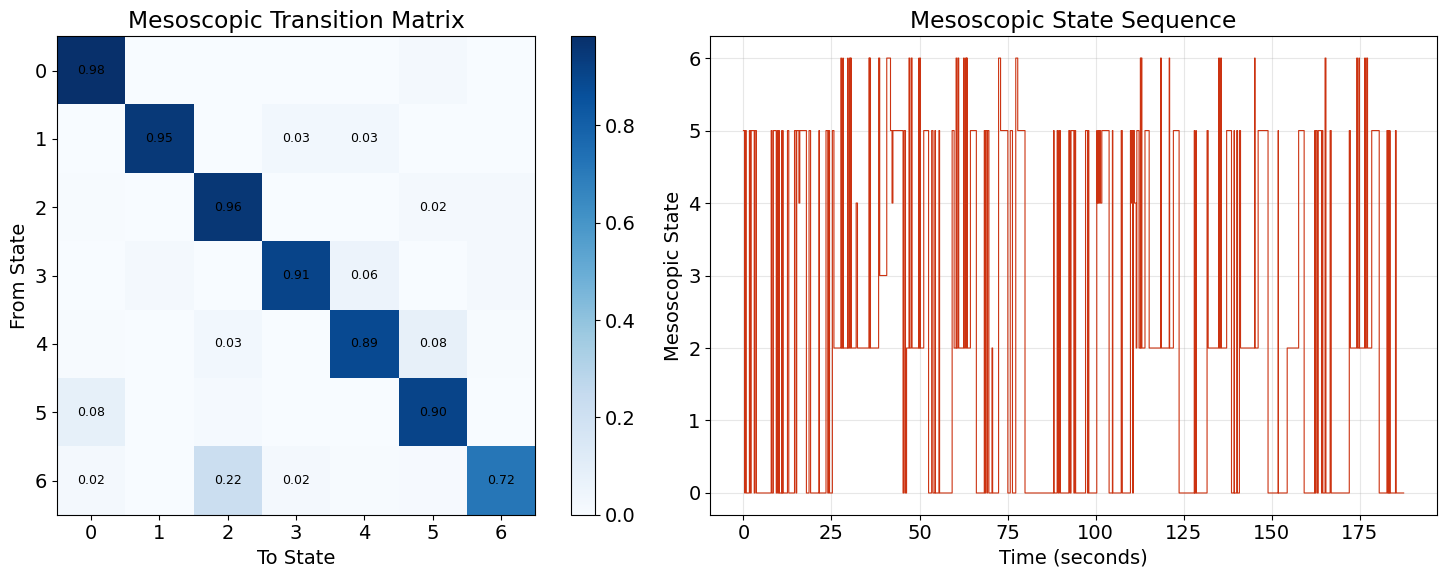

In [53]:
# Compute mesoscopic transition matrix
meso_tm = compute_transition_matrix(meso_sequence, n_transitions=1)

# Visualize as a network diagram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Transition matrix
im = axes[0].imshow(meso_tm, cmap='Blues', vmin=0)
plt.colorbar(im, ax=axes[0], fraction=0.046)
for i in range(n_meso):
    for j in range(n_meso):
        if meso_tm[i, j] > 0.02:
            axes[0].text(j, i, f'{meso_tm[i,j]:.2f}', ha='center', va='center', fontsize=9)
axes[0].set_xlabel('To State')
axes[0].set_ylabel('From State')
axes[0].set_title('Mesoscopic Transition Matrix')

# Time series comparison
plot_range = slice(0, 3000)
time_s = np.arange(len(meso_sequence)) / 16.0

axes[1].plot(time_s[plot_range], meso_sequence[plot_range], 
             drawstyle='steps-post', linewidth=0.8, color=CB_COLORS[3])
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Mesoscopic State')
axes[1].set_title('Mesoscopic State Sequence')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

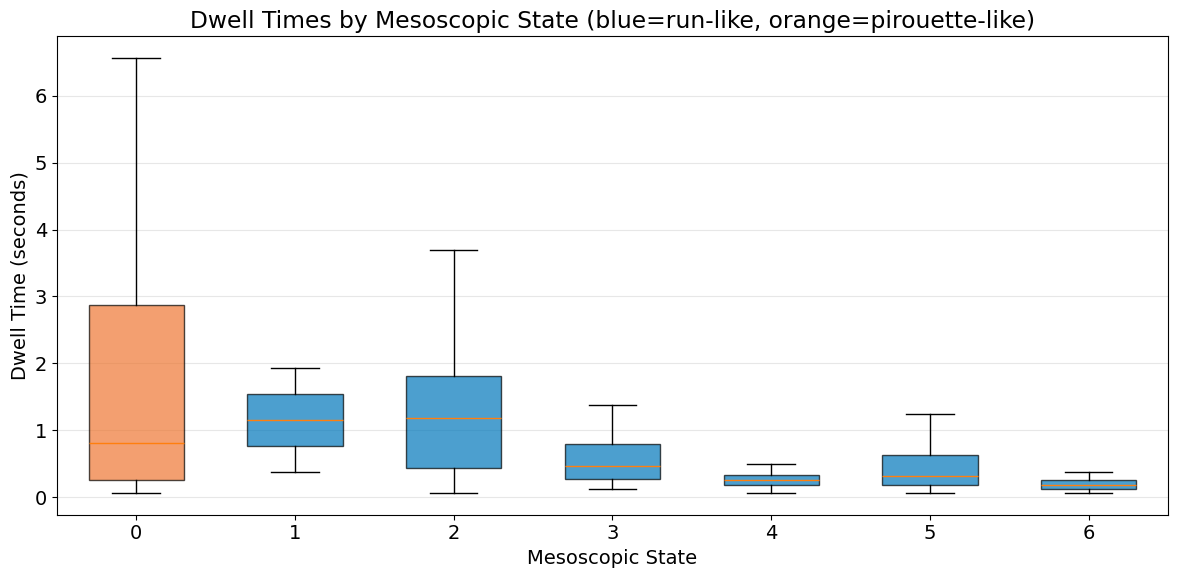

The mesoscopic states reveal finer structure within runs and pirouettes:
  • Different run types (fast/slow, wide/narrow body waves)
  • Different pirouette types (dorsal turns, ventral turns, reversals)


In [54]:
# Mesoscopic dwell time analysis
meso_dwells = {}
for state_id in range(n_meso):
    binary = (meso_sequence == state_id).astype(int)
    in_state = False
    duration = 0
    durations = []
    for val in binary:
        if val == 1:
            duration += 1
            in_state = True
        else:
            if in_state:
                durations.append(duration)
                duration = 0
                in_state = False
    if in_state:
        durations.append(duration)
    meso_dwells[state_id] = np.array(durations) / 16.0  # convert to seconds

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
positions = range(n_meso)
bp = ax.boxplot([meso_dwells[i] for i in range(n_meso)], 
                positions=positions, widths=0.6, patch_artist=True,
                showfliers=False)

for i, patch in enumerate(bp['boxes']):
    pir_frac = np.mean(macro_labels[meso_labels == i])
    color = CB_COLORS[1] if pir_frac > 0.5 else CB_COLORS[0]
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Mesoscopic State')
ax.set_ylabel('Dwell Time (seconds)')
ax.set_title('Dwell Times by Mesoscopic State (blue=run-like, orange=pirouette-like)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("The mesoscopic states reveal finer structure within runs and pirouettes:")
print("  • Different run types (fast/slow, wide/narrow body waves)")
print("  • Different pirouette types (dorsal turns, ventral turns, reversals)")

---

# Project Summary

## What We Accomplished

### Part 2: From Eigenworms to Clusters
✓ Applied **delay embedding** to capture short-time behavioral dynamics  
✓ Performed **K-means clustering** to create our own symbolic dynamics  
✓ **Compared** our clustering to the pre-computed one from Costa et al.  

### Part 3: Transition Matrix & Timescales  
✓ Built a **transition matrix** from the symbolic dynamics  
✓ Understood **eigenvalue = timescale**: $\tau_i = -1/\ln(\lambda_i)$  
✓ Identified the **spectral gap** separating slow and fast modes  
✓ Used **spectral clustering** (eigenvector 2) to find runs vs. pirouettes  

### Part 4: Behavioral State Detection  
✓ Detected **runs and pirouettes** from eigenvector analysis  
✓ Analyzed **dwell time distributions** (approximately exponential)  
✓ Discovered **7 mesoscopic states** with finer behavioral resolution  
✓ Computed **transition rates** between behavioral modes  

## Key Takeaways

1. **Clustering + Markov chains** provide a principled, unsupervised way to discover behavioral states
2. **Eigenvalues of the transition matrix** directly give you the behavioral timescales
3. **Eigenvectors** act as "slow reaction coordinates" that filter out fast noise
4. The **spectral gap** tells you whether there is a natural separation into macrostates
5. These methods recover known biology (runs & pirouettes) without manual thresholding

## Connection to Other Projects

| Method | This Project (C. elegans) | Project 1 (Mice Sniffing) | Project 3 (MoSeq) |
|:---:|:---:|:---:|:---:|
| State representation | Eigenworm PCs | Kinematic features | Depth PCs |
| Clustering | K-means + Markov | Threshold-based | AR-HMM |
| State detection | Spectral analysis | Feature thresholds | Generative model |
| Timescales | Eigenvalue spectrum | Manual definition | AR dynamics |

---

## Further Reading

1. **Costa et al., 2024** — *A Markovian dynamics for C. elegans behavior across scales* (PNAS)
2. **Costa et al., 2023** — *Maximally Predictive States* (Chaos)
3. **Berman et al., 2016** — *Predictability and hierarchy in Drosophila behavior* (PNAS)

**Congratulations!** You've built a complete pipeline from raw postural data to behavioral state detection using Markov chain analysis. 🎉